# 3.3 The time-related dynamic profile of the FG-FC coupling

In [ ]:

from brainspace.plotting import plot_hemispheres
from brainspace.utils.parcellation import map_to_labels
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import scipy as sp
import nilearn as nil
from nilearn import plotting
from scipy.stats import f_oneway
import statsmodels.api as sm
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
import os
import nibabel as nib
from brainspace.mesh.mesh_io import read_surface
from netneurotools.metrics import *
from statsmodels.stats.multitest import multipletests

from PIL import Image, ImageDraw, ImageFont
import pingouin as pg
from scipy.stats import pearsonr
from ana_utils import *
import warnings
warnings.filterwarnings("ignore")

In [41]:
output_dir = f"{PROJ_HOME}/results/3_fg_fc_dynamic_coupling"
os.makedirs(output_dir, exist_ok=True)
print("Output dir:", output_dir)

Output dir: D:\Shanghaitec\PROJECT\CSVD_neo/results/3_fg_fc_dynamic_coupling


## Table S7. Comparison of the r2 of local FG-FC coupling via mixed ANOVA.
## Whole brain CFC

In [42]:
coupling_method = "corr_glob_lm_cfc"

In [43]:
# read data
int_df = pd.read_csv(f"{PROJ_HOME}/results/{coupling_method}/fg-wei-cfc_int.csv").set_index(["pid", "Group","idx","cm"])
wmh_df = pd.read_csv(f"{PROJ_HOME}/results/{coupling_method}/fg-wei-cfc_wmh.csv").set_index(["pid", "Group","idx","cm"])

df_tbl = int_df.rsq - wmh_df.rsq
df_tbl.to_csv(f"{PROJ_HOME}/results/{coupling_method}/fg-wei-cfc_int-wmh.csv")

[ 1  2  3  4  5  6  7  8  9 10]
[ 1  2  3  4  5  6  7  8  9 10]
[ 1  2  3  4  5  6  7  8  9 10]
[ 1  2  3  4  5  6  7  8  9 10]
[ 1  2  3  4  5  6  7  8  9 10]
[ 1  2  3  4  5  6  7  8  9 10]
[ 1  2  3  4  5  6  7  8  9 10]
[ 1  2  3  4  5  6  7  8  9 10]
[ 1  2  3  4  5  6  7  8  9 10]


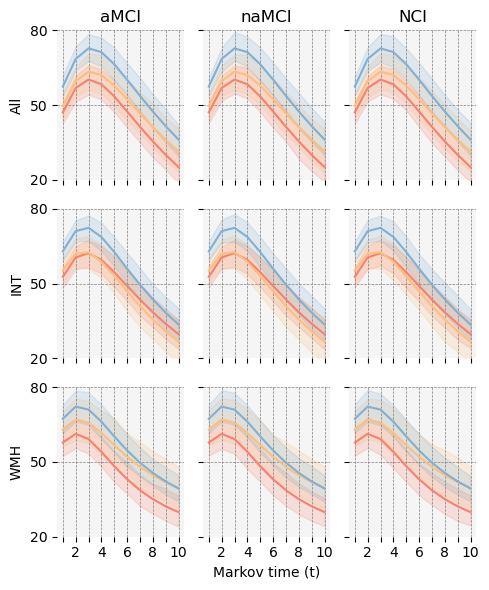

In [45]:
# Paired plot
PLT_LOGHT3 = ["#f1aca7", "#fdba9b", "#b9c8df"]
PLT_LOGHT3 = ["gray", "gray", "gray"]

import numpy as np
from matplotlib.ticker import FixedLocator

fig, axes = plt.subplots(3, 3, figsize=(5, 6))

for j, tract_lab in enumerate(TRACT_LABS):
    for i, group in enumerate(DISGROUPS):
        df = pd.read_csv(f"{PROJ_HOME}/results/{coupling_method}/fg-wei-cfc_{tract_lab}.csv")
        df = df[df.idx >= 1]
        print(df.idx.unique())
        df.dropna()
        sns.lineplot(
            x="idx",
            y="rsq",
            ax=axes[j, i],
            palette=PAL4,
            hue="Group",
            data=df,
            hue_order=DISGROUPS,
            legend=False,
        )

        if i != 0:
            axes[j, i].set_yticklabels([])
            axes[j, i].set_ylabel("")
        else:
            axes[j, i].set_ylabel(["All", "INT", "WMH"][j])
            axes[j, i].set_yticklabels([20, 50, 80])

        if j == 0:  # First row
            axes[j, i].set_title(group)
        axes[j, i].set_ylim(df["rsq"].quantile(0.2), df["rsq"].quantile(0.8))
        axes[j, i].set_yticks((np.linspace(df["rsq"].quantile(0.2), df["rsq"].quantile(0.8), num=3, endpoint=True)))

        axes[j, i].xaxis.set_major_locator(FixedLocator(range(1, 11)))
        if j == 2:  # Last row
            axes[j, i].set_xticklabels([ "", 2, "", 4, "", 6, "", 8, "", 10])
        else:
            axes[j, i].set_xticklabels([])
        axes[j, i].set_xlabel("")
        axes[j, i].spines[:].set_visible(False)

        axes[2, 1].set_xlabel("Markov time (t)")
        axes[j, i].grid(color="gray", linestyle="--", linewidth=0.5, which="major")
        axes[j, i].set_facecolor("whitesmoke")
plt.tight_layout() 
plt.savefig(f"{output_dir}/flow-graph_markov-All.svg", format="svg", dpi=300)
plt.show()


In [7]:
anova_res_df = pd.DataFrame([])
for j, tract_lab in enumerate(TRACT_LABS):
    fg_df = pd.read_csv(
        f"{PROJ_HOME}/results/{coupling_method}/fg-wei-cfc_{tract_lab}.csv"
    )
    fg_df = fg_df[(fg_df.idx < 11) & (fg_df.idx >= 1)]

    df = fg_df

    anova_res = pg.mixed_anova(
        data=df,
        dv="rsq",
        between="Group",
        within="idx",
        subject="pid",
        correction=False,
        effsize="np2",
    )
    anova_res = anova_res.assign(
        Tractography=tract_lab.upper(),
    )
    anova_res_df = pd.concat([anova_res_df, anova_res], ignore_index=True)

anova_res_df.round(4).to_csv(f"{output_dir}/FG_FC_Coupling_Global-level.csv")

## Network-level

In [8]:
coupling_method = "corr_net_lm_cfc"

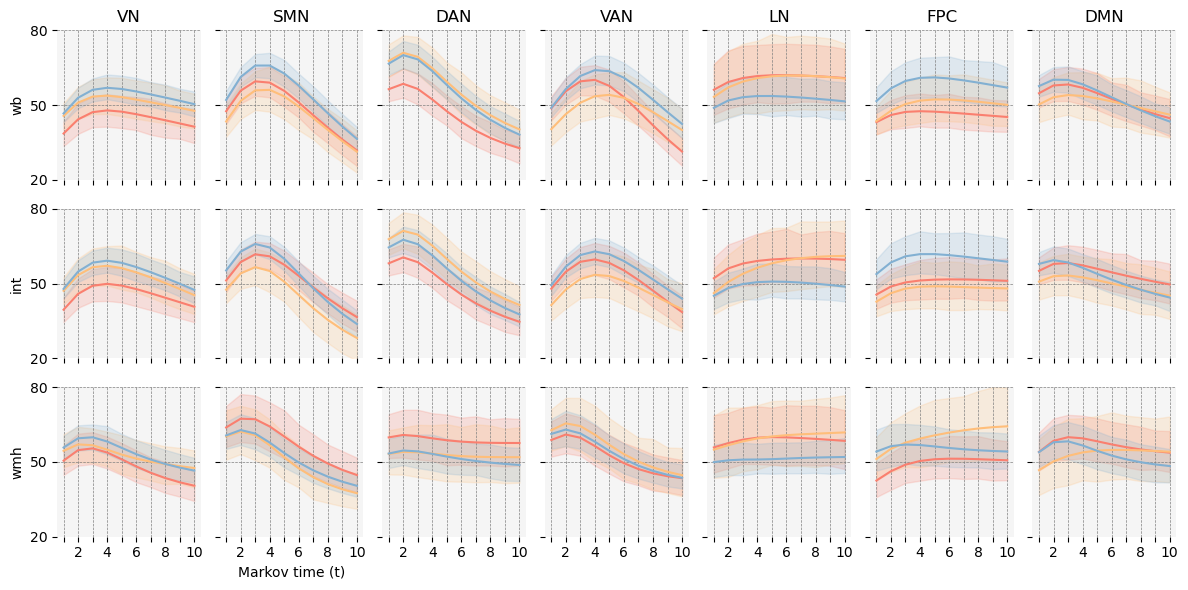

In [9]:
# Paired plot
PLT_LOGHT3 = ["#f1aca7", "#fdba9b", "#b9c8df"]
PLT_LOGHT3 = ["gray", "gray", "gray"]
import pingouin as pg
import numpy as np
from matplotlib.ticker import FixedLocator

fig, axes = plt.subplots(3, 7, figsize=(12, 6))

for j, tract_lab in enumerate(TRACT_LABS):
    for i, net_lab in enumerate(list(NET_LABS.keys())):
        df = pd.read_csv(f"{PROJ_HOME}/results/{coupling_method}/fg-wei-cfc_{tract_lab}.csv")
        df = df[(df.net == net_lab)&(df.idx < 11) & (df.idx >= 1)]
        df.dropna()
        sns.lineplot(
            x="idx",
            y="rsq",
            hue="Group",
            ax=axes[j, i],
            palette=PAL4,
            data=df,
            hue_order=DISGROUPS,
            legend=False 
        )

        if i != 0:
            axes[j, i].set_yticklabels([])
            axes[j, i].set_ylabel("")
        else:
            axes[j, i].set_ylabel(TRACT_LABS[j])
            axes[j, i].set_yticklabels([20,50,80])

        if j == 0:  # First row
            axes[j, i].set_title(NET_LABS[net_lab])
            
        axes[j, i].xaxis.set_major_locator(FixedLocator([0, *range(1, 11)]))
        axes[j, i].set_ylim(df["rsq"].quantile(0.2), df["rsq"].quantile(0.8))
        axes[j, i].set_yticks((np.linspace(df["rsq"].quantile(0.2), df["rsq"].quantile(0.8), num=3, endpoint=True)))

        if j == 2:  # Last row
            axes[j, i].set_xticklabels([0, "", 2, "", 4, "",6, "", 8, "", 10])
        else:
            axes[j, i].set_xticklabels([])
        
        axes[j, i].set_xlabel("")
        axes[j, i].spines[:].set_visible(False)

        axes[2, 1].set_xlabel("Markov time (t)")
        axes[j, i].grid(color="gray", linestyle="--", linewidth=0.5, which="major")
        axes[j, i].set_facecolor("whitesmoke")
plt.tight_layout() 
plt.savefig(f"{output_dir}/flow-graph_markov_sortbynet.svg", format="svg", dpi=300)
plt.show()

In [10]:
anova_res_df = pd.DataFrame([])
for j, tract_lab in enumerate(TRACT_LABS):
    tract_anova_res_df = pd.DataFrame([])
    fg_df = pd.read_csv(
        f"{PROJ_HOME}/results/{coupling_method}/fg-wei-cfc_{tract_lab}.csv"
    )
    fg_df = fg_df[(fg_df.idx < 11) & (fg_df.idx >= 1)]
    for i, net_lab in enumerate(list(NET_LABS.keys())):
        df = fg_df[fg_df.net == net_lab]

        anova_res = pg.mixed_anova(
            data=df,
            dv="rsq",
            between="Group",
            within="idx",
            subject="pid",
            correction=False,
            effsize="np2",
        )
        anova_res = anova_res.assign(
            Network=NET_LABS[net_lab],
            Tractography=tract_lab.upper(),
        )
        tract_anova_res_df = pd.concat([tract_anova_res_df, anova_res], ignore_index=True)
        
    # FDR correction
    tract_anova_res_df["P_corrected"] = tract_anova_res_df.groupby("Source")["p-unc"].transform(
            lambda p: add_statistic_annotation(fdr_correction(p.tolist()))
        )
    anova_res_df = pd.concat([anova_res_df, tract_anova_res_df], ignore_index=True)
anova_res_df.round(4).to_csv(f"{output_dir}/FG_FC_Coupling_Network-level.csv")

## Tmax


In [35]:
tmax_tbl = {
    "Tractography": [],
    "net": [],
    "pid": [],
    "tmax": [],
}
for j, tract_lab in enumerate(TRACT_LABS):
    fg_df = pd.read_csv(
        f"{PROJ_HOME}/results/{coupling_method}/fg-wei-cfc_{tract_lab}.csv"
    )
    for m, net_lab in enumerate(list(NET_LABS)):

        fg_df_net = fg_df[fg_df.net == net_lab]
        for sub_id in df.pid.unique():
            fg_df_net_sub = fg_df_net[fg_df_net.pid == sub_id]
            x = np.array(fg_df_net_sub.idx)
            y = np.array(fg_df_net_sub.rsq)
            coefficients = np.polyfit(x, y, 4)
            fitted_curve = np.poly1d(coefficients)

            max_y = np.max(fitted_curve(x))
            max_t = x[np.argmax(fitted_curve(x))]
            tmax_tbl["Tractography"].append(tract_lab)
            tmax_tbl["tmax"].append(max_t)
            tmax_tbl["net"].append(net_lab)
            tmax_tbl["pid"].append(sub_id)
tmax_df = pd.DataFrame(tmax_tbl)
# Apply the mapping only for existing keys and ignore those that cannot be mapped
tmax_df["Group"] = tmax_df["pid"].map(SUB_ID_DIAG_DICT).dropna()

In [37]:
anova_res_df = pd.DataFrame([])
for j, tract_lab in enumerate(TRACT_LABS):
    tract_anova_res_df = pd.DataFrame([])
    for m, net_lab in enumerate(list(NET_LABS.keys())):
        df = tmax_df[(tmax_df.net == net_lab) & (tmax_df.Tractography == tract_lab)]
        anova_res = pg.anova(df, dv="tmax", between="Group")
        anova_res = anova_res.assign(Network=NET_LABS[net_lab], Tractography=tract_lab)
        tract_anova_res_df = pd.concat(
            [tract_anova_res_df, anova_res], ignore_index=True
        )

    tract_anova_res_df["P_corrected"] = tract_anova_res_df.groupby("Tractography")["p-unc"].transform(
            lambda p: add_statistic_annotation(fdr_correction(p.tolist()))
        )
    anova_res_df = pd.concat([anova_res_df, tract_anova_res_df], ignore_index=True)
anova_res_df.round(4).to_csv(f"{output_dir}/FG_FC_Coupling_Tmax.csv")